# 09 · 토스 심층 플레이 기기는 무엇을 반복했나

**한 줄 질문:** 앞 분석에서 행동 이벤트 31회 이상을 남긴 토스 기기 10대는 첫날 어떤 행동을 깊게 했나?

이 노트북은 가설 판정이나 사람 단위 추적이 아닌 G2 기술적 EDA다. 앞 노트북에서 이미 정한 **31회 이상** 구간을 그대로 쓴다. 완료 기준은 10대의 첫날 행동 총량·행동 종류 수·상위 반복 행동·5개 활동 영역 구성을 기기별로 제시하고, 기록 누락과 내부 테스트 혼입 가능성을 명시하는 것이다.

## 1. 범위와 개인정보 경계

- 원천은 BigQuery GA4 완전 일별 export의 2026-09-04~09-12(KST). 첫 `platform='toss'`가 기록된 날의 토스 이벤트만 사용한다. 게임 전체의 첫 방문일이라는 뜻은 아니다.
- `user_pseudo_id`는 BigQuery 쿼리 안에서만 묶는 키다. 결과에는 행동 횟수 순위에 따라 `T01`~`T10`이라는 임시 이름만 나온다. 이 이름은 영구 사용자 ID가 아니고, 과거·미래 실행의 `T01`과 이어 붙일 수 없다.
- 기록된 `beta_A`·`beta_B`는 제외한다. 토스 집계에서 이 표식은 0건이었으나 미표식 내부 사용자까지 배제할 근거는 없다.
- 행동 목록은 08 노트북과 같다. 자동 GA4 수집, 로그인, 튜토리얼, 경제 장부, `tutorial_skip`을 행동 횟수에서 빼고, 나무 베기 같은 반복 행동은 일어난 횟수만큼 센다.
- W&B 업로드는 안전 검토로 보류된 상태다. 이 노트북과 CSV·PNG는 로컬에만 저장한다.

In [1]:
from pathlib import Path
import os,sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from IPython.display import Markdown,display

ROOT=Path.cwd()
if ROOT.name=='notebooks': ROOT=ROOT.parents[1]
os.chdir(ROOT)
sys.path.insert(0,str(ROOT/'ml'))
from calm_ml import bq,report as R
R.setup()
SQL=ROOT/'ml/sql/g2_toss_deep_device_actions.sql'
SQL_ALL=ROOT/'ml/sql/g2_toss_first_day_behavior.sql'
OUT=ROOT/'ml/reports/g2_toss_deep_device_2026-09-14'
OUT.mkdir(parents=True,exist_ok=True)

AREA_EVENTS={
 '자연·채집':['chop_tree','first_chop','plant_seed','water_crop','harvest_crop','forage_pick','mine_ore'],
 '낚시·바다':['fishing_cast','fishing_catch','fishing_miss','sea_cast','sea_catch','boat_start'],
 '퀘스트·교류':['npc_talk','quest_accept','quest_complete','gift_give'],
 '제작·집':['shop_sell','shop_buy','craft_item','place_decor','house_complete','house_expand','cooking_start','carve_start'],
 '고급 콘텐츠':['mist_purify_start','firefly_swing','coop_build','coop_feed','coop_collect','cafe_serve','photo_capture','dex_open','album_open','leaderboard_open'],
}
KOREAN={
 'mine_ore':'광석 캐기','chop_tree':'나무 베기','npc_talk':'NPC 대화','plant_seed':'씨앗 심기',
 'harvest_crop':'수확','fishing_cast':'낚싯대 던지기','fishing_catch':'물고기 잡기',
 'water_crop':'물 주기','sea_cast':'바다 낚싯대 던지기','quest_accept':'퀘스트 수락',
 'first_chop':'첫 벌목','shop_sell':'상점 판매','quest_complete':'퀘스트 완료',
 'forage_pick':'채집','house_complete':'집 완성','firefly_swing':'반딧불 그네',
}
event_area={event:area for area,events in AREA_EVENTS.items() for event in events}
print('SQL:',SQL)


SQL: /Users/uicheol_hwang/calm_forest/ml/sql/g2_toss_deep_device_actions.sql


## 2. 실행 SQL 원문

이 SQL만 표본과 순위를 정의한다. 실제 기기 ID와 정확한 이벤트 시각은 조회 결과에 없다. `T01`은 첫날 행동 횟수가 가장 많은 익명 기기다.

In [2]:
display(Markdown('```sql\n'+SQL.read_text(encoding='utf-8')+'\n```'))
d=bq.read_sql_file(str(SQL))
all_devices=bq.read_sql_file(str(SQL_ALL))
total_all=int(all_devices.deliberate_events.sum())
assert d.device_label.nunique()==10, '31회 이상 기기 수가 이전 분석과 달라졌다'
assert d.groupby('device_label').event_count.sum().eq(d.groupby('device_label').action_events.first()).all()
assert set(d.event_name).issubset(set(event_area)), '새 행동 이벤트가 영역 매핑에 없다'
d['영역']=d.event_name.map(event_area)
d['행동']=d.event_name.map(lambda x: KOREAN.get(x,x))
print('기기 수:',d.device_label.nunique(),'행동 유형별 집계 행:',len(d))


```sql
-- G2: which deliberate actions the 10 deepest Toss-observed devices repeated
-- on their first Toss-observed day, 2026-09-04..09-12 KST.
-- Deep = >=31 deliberate events (bin fixed in notebook 08 before this query).
-- Toss uses event parameter platform='toss'; GA4 traffic source is not used.
-- Exclude beta_A/beta_B marked devices. Automatic events, login, onboarding,
-- economy bookkeeping, and tutorial_skip are not deliberate actions.
-- user_pseudo_id is only an internal grouping key; no ID, exact timestamp,
-- account data, or raw event row is returned.
WITH toss_events AS (
  SELECT
    user_pseudo_id,
    DATE(TIMESTAMP_MICROS(event_timestamp), 'Asia/Seoul') AS day,
    event_name,
    (SELECT ep.value.int_value FROM UNNEST(event_params) ep
      WHERE ep.key = 'ga_session_id' LIMIT 1) AS ga_session_id,
    (SELECT up.value.string_value FROM UNNEST(user_properties) up
      WHERE up.key = 'ab_variant' LIMIT 1) AS ab_variant
  FROM `calm-forest.analytics_547127440.events_*`
  WHERE _TABLE_SUFFIX NOT LIKE 'intraday_%'
    AND user_pseudo_id IS NOT NULL
    AND DATE(TIMESTAMP_MICROS(event_timestamp), 'Asia/Seoul')
        BETWEEN DATE '2026-09-04' AND DATE '2026-09-12'
    AND (SELECT ep.value.string_value FROM UNNEST(event_params) ep
         WHERE ep.key = 'platform' LIMIT 1) = 'toss'
),
first_toss AS (
  SELECT user_pseudo_id, MIN(day) AS first_toss_day
  FROM toss_events GROUP BY 1
),
first_day AS (
  SELECT e.*
  FROM toss_events e JOIN first_toss f USING (user_pseudo_id)
  WHERE e.day = f.first_toss_day
),
allowed AS (
  SELECT action_name FROM UNNEST([
    'chop_tree','first_chop','plant_seed','water_crop','harvest_crop','forage_pick',
    'mine_ore','fishing_cast','fishing_catch','fishing_miss','sea_cast','sea_catch',
    'shop_sell','shop_buy','craft_item','place_decor','house_complete','house_expand',
    'npc_talk','quest_accept','quest_complete','gift_give','cooking_start','carve_start',
    'boat_start','mist_purify_start','firefly_swing','coop_build','coop_feed','coop_collect',
    'cafe_serve','photo_capture','dex_open','album_open','leaderboard_open'
  ]) AS action_name
),
device_totals AS (
  SELECT
    user_pseudo_id,
    COUNTIF(event_name IN (SELECT action_name FROM allowed)) AS action_events,
    COUNT(DISTINCT IF(event_name IN (SELECT action_name FROM allowed),
                      event_name, NULL)) AS action_kinds,
    COUNT(DISTINCT ga_session_id) AS observed_ga_sessions,
    LOGICAL_OR(REGEXP_CONTAINS(COALESCE(ab_variant,''),r'^beta_[AB]$')) AS beta_marked
  FROM first_day GROUP BY 1
),
ranked AS (
  SELECT
    user_pseudo_id,
    action_events,
    action_kinds,
    observed_ga_sessions,
    ROW_NUMBER() OVER (ORDER BY action_events DESC, user_pseudo_id) AS depth_rank
  FROM device_totals
  WHERE NOT beta_marked
),
action_counts AS (
  SELECT
    user_pseudo_id, event_name, COUNT(*) AS event_count
  FROM first_day
  WHERE event_name IN (SELECT action_name FROM allowed)
  GROUP BY 1,2
)
SELECT
  FORMAT('T%02d', r.depth_rank) AS device_label,
  r.action_events,
  r.action_kinds,
  r.observed_ga_sessions,
  a.event_name,
  a.event_count
FROM ranked r
JOIN action_counts a USING (user_pseudo_id)
WHERE r.action_events >= 31
ORDER BY r.depth_rank, a.event_count DESC, a.event_name;

```

/Users/uicheol_hwang/calm_forest/ml/.venv/lib/python3.12/site-packages/google/cloud/bigquery/table.py:2128: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


기기 수: 10 행동 유형별 집계 행: 168


/Users/uicheol_hwang/calm_forest/ml/.venv/lib/python3.12/site-packages/google/cloud/bigquery/table.py:2128: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


## 3. 기기별 행동 총량과 종류

먼저 원시 분자부터 본다. `행동 이벤트`는 반복 횟수를 포함하고, `행동 종류`는 서로 다른 이벤트 이름의 수다. `관측 GA 세션 ID`는 GA4에 남은 세션 식별자 수이지 정확한 플레이 세션 수를 보장하지 않는다.

In [3]:
summary=d.groupby('device_label',as_index=False).agg(
 행동_이벤트=('action_events','first'),행동_종류=('action_kinds','first'),
 관측_GA_세션_ID=('observed_ga_sessions','first'))
summary['전체_행동_비중']=summary['행동_이벤트']/total_all
summary.to_csv(OUT/'deep_device_summary.csv',index=False)
display(summary)
print('10대 행동 합계:',int(summary['행동_이벤트'].sum()),
      '전체 토스 첫날',total_all,'건 중 비중:',round(summary['행동_이벤트'].sum()/total_all*100,1),'%')


,device_label,행동_이벤트,행동_종류,관측_GA_세션_ID,전체_행동_비중
0,T01,843,28,1,0.288402
1,T02,545,20,1,0.186452
2,T03,389,15,1,0.133082
3,T04,331,18,2,0.11324
4,T05,258,19,1,0.088265
5,T06,205,26,1,0.070133
6,T07,85,13,1,0.02908
7,T08,55,12,1,0.018816
8,T09,47,10,2,0.016079
9,T10,38,7,1,0.013


10대 행동 합계: 2796 전체 토스 첫날 2923 건 중 비중: 95.7 %


g2_toss_deep_device_totals.png  981x650px


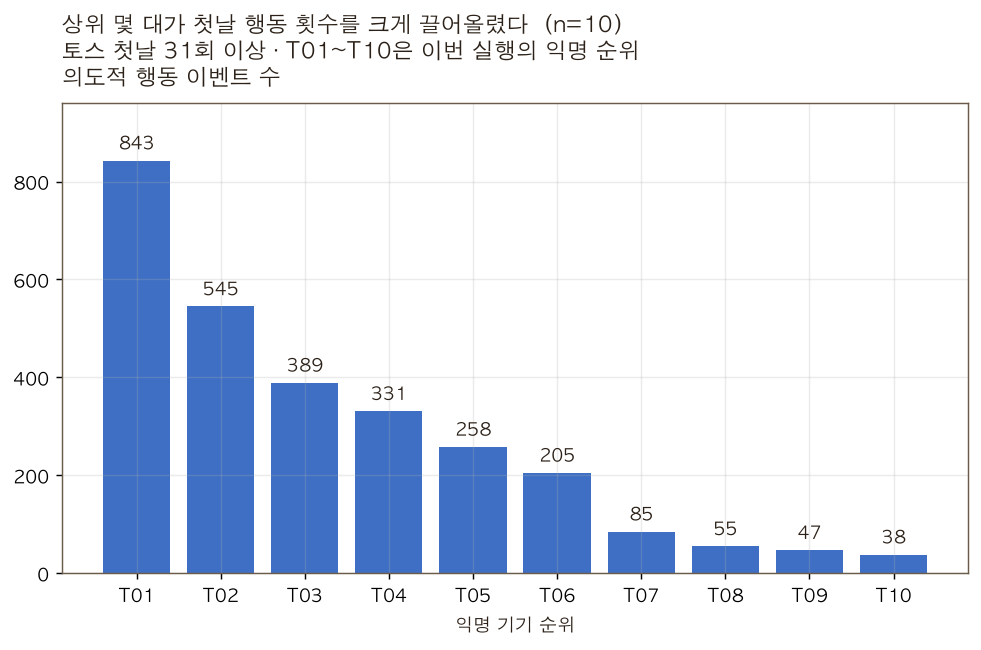

In [4]:
fig,ax=R.new('상위 몇 대가 첫날 행동 횟수를 크게 끌어올렸다',10,
             sub='토스 첫날 31회 이상 · T01~T10은 이번 실행의 익명 순위',ylab='의도적 행동 이벤트 수',figsize=(9,4.7))
bars=ax.bar(summary.device_label,summary['행동_이벤트'],color=R.PALETTE[1])
ax.bar_label(bars,padding=3);ax.set_ylim(0,summary['행동_이벤트'].max()*1.14)
ax.set_xlabel('익명 기기 순위')
chart_total=R.save(fig,ax,'g2_toss_deep_device_totals')
print(R.check(chart_total));display(R.show(chart_total))


## 4. 기기마다 많이 반복한 행동

각 기기의 상위 네 행동을 실제 이벤트 횟수와 함께 읽는다. 예를 들어 `T01`의 채굴 172회는 광석을 캔 이벤트가 172번 기록됐다는 뜻이지, 광산 방문이 172회라는 뜻은 아니다. `first_chop`과 `chop_tree`처럼 의미가 가까운 이벤트도 이름별로 따로 센다.

In [5]:
top=d.sort_values(['device_label','event_count'],ascending=[True,False]).groupby('device_label',sort=True).head(4)
top_table=top[['device_label','행동','event_count']].rename(columns={'device_label':'익명 기기','event_count':'기록 횟수'})
top_table.to_csv(OUT/'deep_device_top_actions.csv',index=False)
display(top_table)


,익명 기기,행동,기록 횟수
0,T01,광석 캐기,172
1,T01,나무 베기,164
2,T01,NPC 대화,79
3,T01,씨앗 심기,74
28,T02,나무 베기,180
29,T02,낚싯대 던지기,81
30,T02,물고기 잡기,72
31,T02,NPC 대화,40
48,T03,씨앗 심기,174
49,T03,수확,89


g2_toss_deep_device_action_heatmap.png  1115x746px


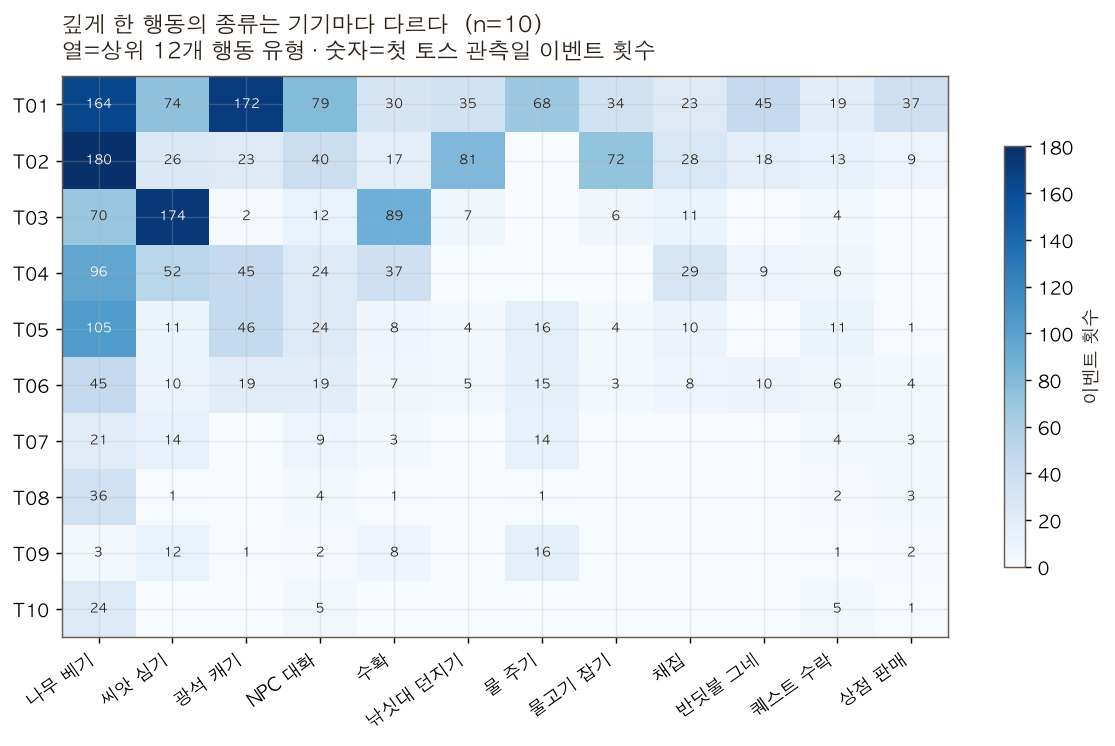

In [6]:
top_events=d.groupby('event_name').event_count.sum().sort_values(ascending=False).head(12).index
matrix=d[d.event_name.isin(top_events)].pivot_table(index='device_label',columns='event_name',values='event_count',aggfunc='sum',fill_value=0)
matrix=matrix.reindex(index=summary.device_label,columns=top_events,fill_value=0)
fig,ax=R.new('깊게 한 행동의 종류는 기기마다 다르다',10,
             sub='열=상위 12개 행동 유형 · 숫자=첫 토스 관측일 이벤트 횟수',figsize=(11,5.6))
im=ax.imshow(matrix.to_numpy(dtype=float),cmap='Blues',aspect='auto',vmin=0)
ax.set_yticks(range(len(matrix.index)),matrix.index)
ax.set_xticks(range(len(matrix.columns)),[KOREAN.get(x,x) for x in matrix.columns],rotation=35,ha='right')
for i in range(matrix.shape[0]):
    for j in range(matrix.shape[1]):
        v=int(matrix.iat[i,j])
        if v: ax.text(j,i,str(v),ha='center',va='center',fontsize=7,
                      color='white' if v>90 else R.INK)
fig.colorbar(im,ax=ax,label='이벤트 횟수',shrink=.75)
chart_heat=R.save(fig,ax,'g2_toss_deep_device_action_heatmap',zero_base=False)
print(R.check(chart_heat));display(R.show(chart_heat))


## 5. 활동 영역 구성

같은 행동을 반복한 양을 영역별로 더한 구성비다. 한 기기가 여러 영역에 도달했다는 사실과 각 영역에 얼마나 시간을 썼는지는 다르다. 반복 이벤트 횟수는 체류시간의 대리변수로 쓰지 않는다.

영역,자연·채집,낚시·바다,퀘스트·교류,제작·집,고급 콘텐츠
device_label,,,,,
T01,532,78,116,60,57
T02,275,160,63,25,22
T03,347,13,20,4,5
T04,264,4,35,10,18
T05,197,8,44,7,2
T06,105,37,31,12,20
T07,53,12,16,4,0
T08,40,0,8,6,1
T09,41,0,4,2,0


g2_toss_deep_device_area_mix.png  1008x753px


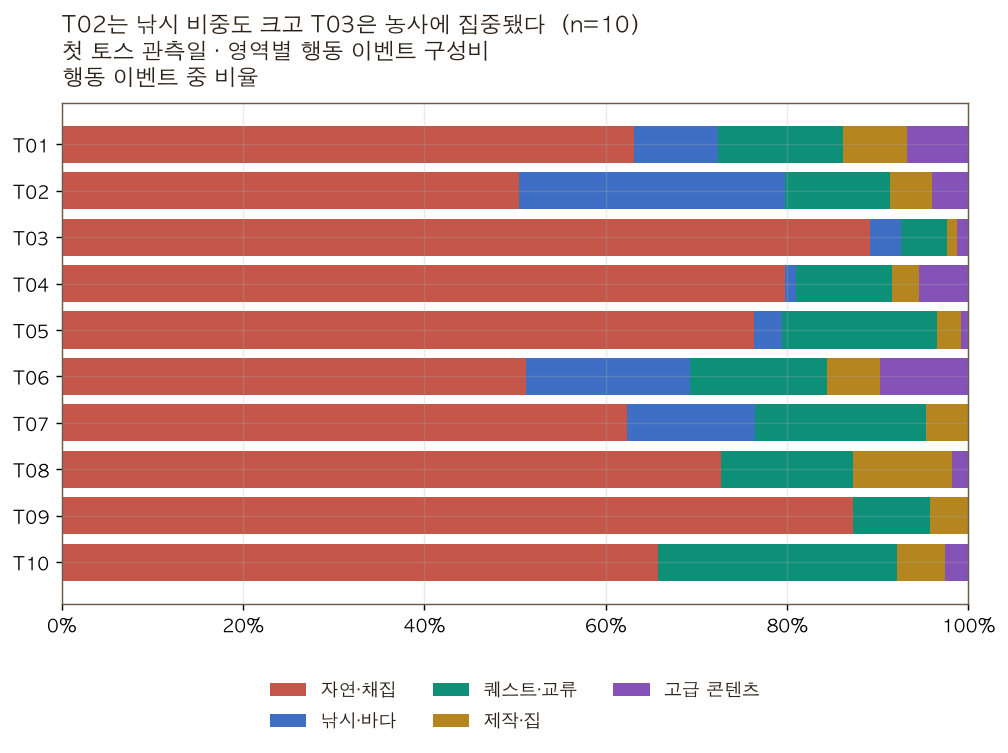

In [7]:
area=d.pivot_table(index='device_label',columns='영역',values='event_count',aggfunc='sum',fill_value=0)
area=area.reindex(index=summary.device_label,columns=list(AREA_EVENTS),fill_value=0)
assert area.sum(axis=1).eq(summary.set_index('device_label')['행동_이벤트']).all()
area.to_csv(OUT/'deep_device_area_counts.csv')
display(area)
share=area.div(area.sum(axis=1),axis=0)
fig,ax=R.new('T02는 낚시 비중도 크고 T03은 농사에 집중됐다',10,
             sub='첫 토스 관측일 · 영역별 행동 이벤트 구성비',ylab='행동 이벤트 중 비율',figsize=(9,5))
left=np.zeros(len(share))
for i,col in enumerate(share.columns):
    values=share[col].to_numpy()
    ax.barh(share.index,values,left=left,color=R.PALETTE[i],label=col)
    left+=values
ax.invert_yaxis();ax.set_xlim(0,1)
ax.xaxis.set_major_formatter(mticker.PercentFormatter(1))
ax.legend(loc='upper center',bbox_to_anchor=(.5,-.12),ncol=3,frameon=False)
chart_area=R.save(fig,ax,'g2_toss_deep_device_area_mix',zero_base=False)
print(R.check(chart_area));display(R.show(chart_area))


## 6. 그래서 크기가 얼마나 되나

아래 문장은 실행 결과에서 숫자를 다시 만든다. 높은 횟수가 실제 선호인지, 내부 점검·자동 반복인지 여기서 확정하지 않는다.

In [8]:
deep_total=int(summary['행동_이벤트'].sum())
display(Markdown(f'''첫날 행동 31회 이상을 남긴 **10대**가 토스 첫날 전체 {total_all:,}건 중 **{deep_total:,}건({deep_total/total_all:.1%})**을 기록했다. `T01`은 {int(summary.iloc[0]['행동_이벤트']):,}건으로 가장 많았지만, 10대의 상위 반복 행동은 서로 같지 않다. `T02`는 벌목·낚시, `T03`은 씨앗 심기·수확이 두드러진다. 이 표는 행동의 **종류와 반복량**을 보여주며 게임 경로나 체류시간은 보여주지 않는다.'''))


첫날 행동 31회 이상을 남긴 **10대**가 토스 첫날 전체 2,923건 중 **2,796건(95.7%)**을 기록했다. `T01`은 843건으로 가장 많았지만, 10대의 상위 반복 행동은 서로 같지 않다. `T02`는 벌목·낚시, `T03`은 씨앗 심기·수확이 두드러진다. 이 표는 행동의 **종류와 반복량**을 보여주며 게임 경로나 체류시간은 보여주지 않는다.

## 7. 이 숫자로 말할 수 없는 것

- `T01`~`T10`은 임시 순위다. 실제 사람의 계정·성별·나이·영구 ID가 아니며, 다음 실행의 같은 라벨과 이어 붙일 수 없다.
- 베타 A/B 표식이 없다고 해서 내부 사용자·개발 점검이 없다는 뜻은 아니다. 특히 한 기기에 843건이 몰린 꼬리는 미표식 테스트에 민감하다.
- `mine_ore` 172회는 채굴 이벤트 172건이다. 방문 횟수·광산 체류시간·좋아하는 콘텐츠로 곧장 바꿔 읽을 수 없다.
- 하나의 게임 행동이 여러 이벤트 이름을 낼 수 있다. `first_chop`과 `chop_tree`의 중복 계측 여부를 별도로 감사하지 않았으므로 절대 횟수는 주의해서 읽는다.
- 첫 토스 관측일은 게임 최초 방문이 아니다. 토스 표식 전 이탈은 표본에 들어오지 않는다. GA4 9/13 일별 export는 아직 없어 9/12까지만 썼다.
- 10대만 자세히 본 결과다. 나머지 39대가 같은 패턴이라는 뜻이 아니다. 행동 순서·이탈 원인은 이 표로 판단할 수 없다.

## 8. 다음에 확인할 것

상위 기기의 반복 이벤트가 내부 점검인지 실제 플레이인지 분리하려면, 내부 사용자 표식과 계측 중복부터 확인해야 한다. 이 단계에서는 원인을 추정하지 않고 멈춘다.

## 9. 분석 가정과 기록

| 가정 | 근거 | 신뢰 | 틀렸을 때 영향 | 검증 |
|---|---|---|---|---|
| GA4 이벤트 `platform=toss`는 토스 웹뷰 행동 | 게임 분석 코드 | 중 | 표본 오분류 | 자체 세션 플랫폼과 교차 확인 |
| 31회 이상은 심층 행동 구간 | 08 노트북의 사전 구간 | 중 | 기기 선택 변경 | 다른 문턱은 별도 민감도 분석 |
| `beta_A/B` 표식으로 알려진 테스터 제외 | A/B 배정 기록 | 중 | 내부 행동 혼입 | 명단-기기 매핑 커버리지 확인 |
| 이벤트 횟수는 반복 행동량 | GA4 카운트 | 중 | 중복 계측 시 과대 | 이벤트 쌍·디바운스 감사 |

W&B 업로드는 앞선 안전 검토에서 보류됐다. 이 노트북은 로컬 실행만 한다.